In [6]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from matplotlib.pyplot import rc_context
import os
import seaborn as sns
import numpy as np

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm,Normalize

In [7]:
# Path definition
Inputpath = "../data_wildfire/"
Outputpath = "../fig_wildfire/"
Resultpath = "../numerical_result_wf/"

df_arc = pd.read_excel(os.path.join(Inputpath,"arcs_sonoma_15min.xlsx"), header = 0)
df_node = pd.read_excel(os.path.join(Inputpath,"nodes_sonoma_15min.xlsx"), header = 0)
df_S_nodes = pd.read_excel(os.path.join(Inputpath,"safe_nodes_15min.xlsx"), header = 0)
df_S_nodes = df_S_nodes[df_S_nodes['Safe'] == 1]

In [8]:
population_color = df_node['population'].tolist()

In [9]:
# basemap

# [llcrnrlon, llcrnrlat, urcrnrlon, urcrnrlat]
coords = [-123.31,37.95,-121.98,38.86,36]



m = Basemap(projection='merc',
            llcrnrlon = coords[0],
            llcrnrlat = coords[1],
            urcrnrlon = coords[2],
            urcrnrlat = coords[3],
            resolution = 'i',
            #lat_ts = 0,
           suppress_ticks=True)
           #epsg=5520)


# networkx drawing
G = nx.Graph()
nodes = df_node['Nodes'].tolist()
G.add_nodes_from(nodes)

for i in range(len(df_arc)):
    from_node = df_arc.iloc[i]['From']
    to_node = df_arc.iloc[i]['To']
    G.add_edge(from_node,to_node)
#labels = [str(i) for i in nodes]
node_lats = df_node['Lat'].tolist() # north south
node_lons = df_node['Long'].tolist() # east west
mx,my = m(node_lons,node_lats)
pos = {}
for node in nodes:
    pos[node] = (mx[node-1],my[node-1])


vmin = min(population_color)
vmax = max(population_color)

cmap = sns.color_palette("Spectral", as_cmap=True)


C:\Users\lucy_\AppData\Local\Temp\ipykernel_5508\1305561118.py:23: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, fraction=0.046, pad=0.04, shrink=0.3)


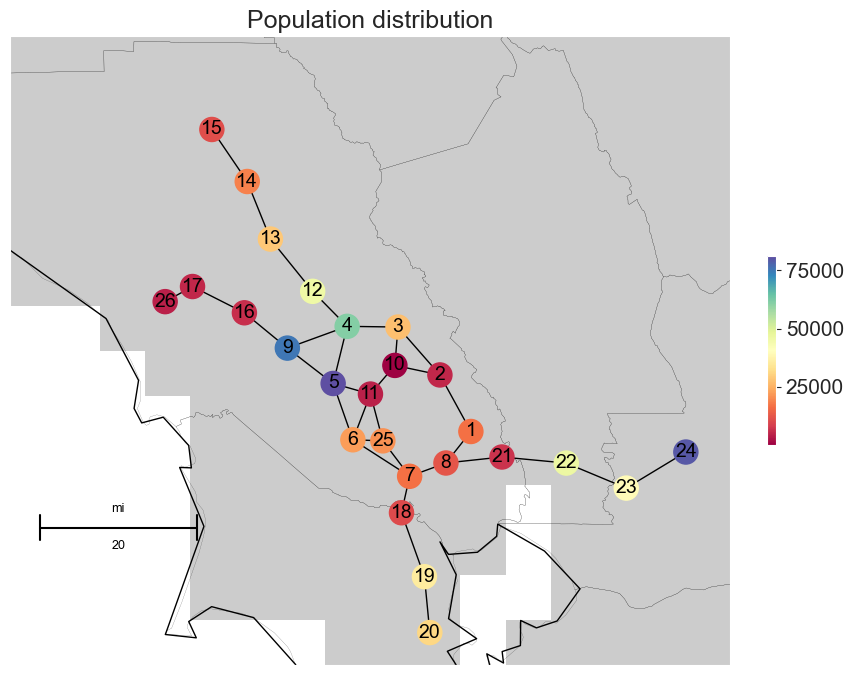

In [10]:
with rc_context({'figure.figsize': (10,7), 'font.size':15}):

    # basemap drawing
    m.drawcounties()
    m.drawcoastlines()
    m.drawlsmask(resolution = 'i') #land_color = "#ddaa66", ocean_color="#7777ff",

    # draw a map scale
    m.drawmapscale(
        coords[0]+0.2, coords[1]+0.2,
        coords[0], coords[1],
        20.,
        units='mi')

    nx.draw_networkx(G,pos,node_size=300,node_color=population_color,cmap=cmap,
                     with_labels=True, font_size=14
                    )
    sm = plt.cm.ScalarMappable(cmap=cmap,norm=Normalize(vmin=vmin,vmax=vmax))
    sm._A = []
    # ax = plt.gca()
    # divider = make_axes_locatable(ax)
    # cax = divider.append_axes("right", size="4%", pad=0.05)
    plt.colorbar(sm, fraction=0.046, pad=0.04, shrink=0.3)
    plt.title('Population distribution')
    # plt.colorbar(shrink=0.3)
    # fig.colorbar(sm, orientation="verticle")
    plt.tight_layout()

    plt_filename = "population_density.png"
    outname = os.path.join(Outputpath,plt_filename)
    plt.savefig(outname,dpi=300)
    plt.show()